In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import glob
import csv
import ast
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [46]:
#  fetch assets
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
xgroup2ds_ab = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv')

## Create dict 'loo' with all Leave One Out results

In [4]:
folder_path = '../LOO/'
files_pattern = '*.pkl.gz'
files = glob.glob(folder_path + files_pattern)

loo = {}

# Iterate over each file
for file_path in files:
    # Extract the fold number from the file name
    fold_number = file_path.split('__')[1].split('.')[0]
    
    # Read the pickle file and populate loo dictionary
    loo[fold_number] = pd.read_pickle(file_path)

## Collect the network sizes in cpds_subiter[1] from each dict in loo

In [6]:
# create xgroup2networkSize dict

xgroup2ns = {}
for xgroup in loo:
    if xgroup not in ['spontaneous', 'fold_independent']:  # ignore non-fold leave-one-out reults
        xgroup2ns[xgroup] = len(loo[xgroup].cpds_subiter[1])

In [7]:
len(xgroup2ns)

396

In [ ]:
# save dict as csv
# dict2csv(xgroup2ns, '../data/assets/xgroup2/xgroup2networkSize.csv')

# create x2rulesNum from rn2rules

In [47]:
def numRulesWith(xgroup, rn2rules):
    numRules = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

In [48]:
x2rulesNum = {}
for xgroup in xgroup2ns.keys():
    x2rulesNum[xgroup] = numRulesWith(xgroup, rn2rules)

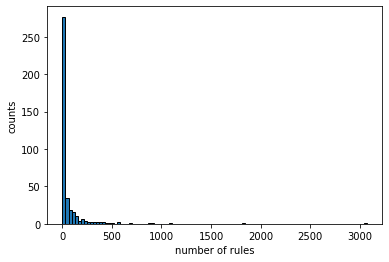

In [16]:
histogram(x2rulesNum, bins=100, x_axis = 'number of rules')

In [17]:
# dict2csv(x2rulesNum, '../data/assets/xgroup2/xgroup2rulesNum.csv')

# scatterplot: network size vs. #rules

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


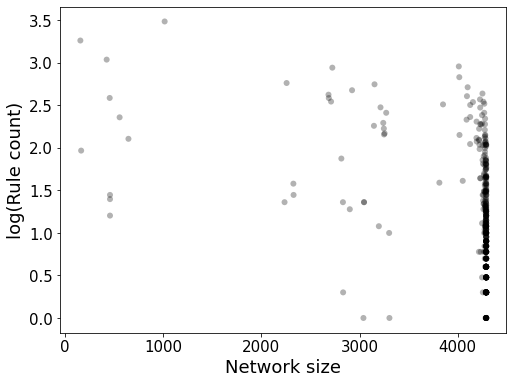

In [153]:
corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='k', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Rule count)', fontsize=18)
plt.tick_params(labelsize=15)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# divide xgroups based on two 'network size' thresholds: 1500 and 3600

In [49]:
# network size < 1500 => first10

xgroup2sub1500 = {}
xgroup2sup1500 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 1500:
        xgroup2sub1500[xgroup] = xgroup2ns[xgroup]
    else:
        xgroup2sup1500[xgroup] = xgroup2ns[xgroup]

In [50]:
# network size < 3600 => group1
# network size >= 3600 => group2

groupOne2ns = {}
groupTwo2ns = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        groupOne2ns[xgroup] = xgroup2ns[xgroup]
    else:
        groupTwo2ns[xgroup] = xgroup2ns[xgroup]

In [51]:
first10 = list(xgroup2sub1500.keys())
group1 = list(groupOne2ns.keys())
group2 = list(groupTwo2ns.keys())

# The first division is CoA; second division is Oxygen

### first10 vs. others

In [13]:
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

In [44]:
cpds = list(loo['2002'].cpds_folditer.keys())

In [280]:
divider_cpds_first10 = []  # list of cpds that don't exist in any first10 LOO networks, but always exist others
for cpd in cpds:
    divide = [True, True]
    for x in first10:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
            divide[0] = False
            break
    for x in (set(group2) | set(group1)) - first10:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
            divide[1] = False
            break

    if False not in divide:
        print(f"{cpd} {cpd2name[cpd]} divides first10 vs. others")
        divider_cpds_first10.append(cpd)

C20843 N5-Phenyl-L-glutamine divides first10 vs. others
C01920 Geranoyl-CoA divides first10 vs. others
C06473 2-Keto-D-gluconic acid divides first10 vs. others
C00879 D-Galactarate divides first10 vs. others
C09810 Cyclohexa-1,4-diene-1-carbonyl-CoA divides first10 vs. others
C00333 D-Galacturonate divides first10 vs. others
C03561 (R)-3-Hydroxybutanoyl-CoA divides first10 vs. others
C06440 2-Dehydro-D-glucono-1,5-lactone divides first10 vs. others
C21643 3-Dehydro-scyllo-inosose divides first10 vs. others
C05360 Diimine divides first10 vs. others
C05402 Melibiose divides first10 vs. others
C03345 2-Methylbut-2-enoyl-CoA divides first10 vs. others
C11354 2-Hydroxy-cis-hex-2,4-dienoate divides first10 vs. others
C00024 Acetyl-CoA divides first10 vs. others
C03383 D-Galactono-1,4-lactone divides first10 vs. others
C01998 Acrylonitrile divides first10 vs. others
C00877 Crotonoyl-CoA divides first10 vs. others
C00894 Propenoyl-CoA divides first10 vs. others
C00261 Benzaldehyde divides firs

C01500 Geraniol divides first10 vs. others
C05359 e- divides first10 vs. others
C00350 Phosphatidylethanolamine divides first10 vs. others
C13482 Phosphodimethylethanolamine divides first10 vs. others
C03692 1,2-Diacyl-3-beta-D-galactosyl-sn-glycerol divides first10 vs. others
C05231 L-3-Aminobutyryl-CoA divides first10 vs. others
C04405 (2S,3S)-3-Hydroxy-2-methylbutanoyl-CoA divides first10 vs. others
C06038 Acyl1-monogalactosyl-diacylglycerol divides first10 vs. others
C05758 trans-Dodec-2-enoyl-[acp] divides first10 vs. others
C12366 Tetracenomycin F2 divides first10 vs. others
C02630 2-Hydroxyglutarate divides first10 vs. others
C21644 5-Dehydro-L-gluconate divides first10 vs. others
C12621 trans-3-Hydroxycinnamate divides first10 vs. others
C02659 Acetone cyanohydrin divides first10 vs. others
C04438 1-Acyl-sn-glycero-3-phosphoethanolamine divides first10 vs. others
C09819 (2S)-[(R)-Hydroxy(phenyl)methyl]succinyl-CoA divides first10 vs. others
C02488 (R)-2-Ethylmalate divides firs

In [281]:
len(divider_cpds_first10)

316

In [286]:
'C00010' in divider_cpds_first10  # CoA

True

In [284]:
for c in divider_cpds_first10:
    if c.startswith('Z'):
        print(c, cpd2name[c])

Z00037 Pantetheine
Z00051 Coenzyme A
Z00038 Phosphopantetheine
Z00007 CoB


In [305]:
for cpd in divider_cpds_first10:
    if int(cpd[-5:]) < 100:
        print(cpd, cpd2name[cpd])

C00024 Acetyl-CoA
Z00037 Pantetheine
C00091 Succinyl-CoA
C00010 CoA
Z00051 Coenzyme A
C00040 Acyl-CoA
C00083 Malonyl-CoA
Z00038 Phosphopantetheine
Z00007 CoB


In [ ]:
# not ATP or NDPH?

In [294]:
cpd = 'C00002'
print(cpd2name[cpd])
print('--------------')
for x in first10:
    print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# you can get ATP without Rossmann, HUP, or alpha/beta-Hammerhead/Barrel-sandwich hybrid?

ATP
--------------
X325: 20
X2005: 20
X4952: N/A
X2003: 20
X4953: N/A
X602: N/A
X206: N/A
X2002: N/A
X218: N/A
X2007: N/A


In [295]:
cpd = 'C00004'
print(cpd2name[cpd])
print('--------------')
for x in first10:
    print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# you can get NADH without Rossmann?

NADH
--------------
X325: N/A
X2005: N/A
X4952: N/A
X2003: 22
X4953: N/A
X602: N/A
X206: N/A
X2002: N/A
X218: N/A
X2007: N/A


### group1 vs. group2

In [52]:
divider_cpds_g1g2 = []  # list of cpds that don't exist in any group1 LOO networks, but always exist in group2 LOO
for cpd in cpds:
    divide = [True, True]
    for x in group1:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
            divide[0] = False
            break
    for x in group2:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
            divide[1] = False
            break

    if False not in divide:
        print(f"{cpd} {cpd2name[cpd]} divides group1 vs. group2")
        divider_cpds_g1g2.append(cpd)

C21124 IPA imine divides group1 vs. group2
C03666 2-Carboxy-cis,cis-muconate divides group1 vs. group2
C11631 9-Riburonosylhypoxanthine divides group1 vs. group2
C15603 Hydroquinone divides group1 vs. group2
C04106 2-(Hydroxymethyl)-4-oxobutanoate divides group1 vs. group2
C02298 N-Acetylindoxyl divides group1 vs. group2
C02779 2-Dehydro-D-glucose divides group1 vs. group2
C11145 Methanesulfonic acid divides group1 vs. group2
C21803 8-Demethyl-8-formylriboflavin 5'-phosphate divides group1 vs. group2
C00472 p-Benzoquinone divides group1 vs. group2
C17756 2-Descarboxy-cyclo-dopa divides group1 vs. group2
C03824 2-Aminomuconate semialdehyde divides group1 vs. group2
C05856 Thiamine aldehyde divides group1 vs. group2
C15883 2,3-Dimethyl-5-phytylquinol divides group1 vs. group2
C02892 Thiamine acetic acid divides group1 vs. group2
C01133 N-Acetyl-D-glucosaminate divides group1 vs. group2
C12622 cis-3-(3-Carboxyethenyl)-3,5-cyclohexadiene-1,2-diol divides group1 vs. group2
C20526 10,11-Epox

In [53]:
len(divider_cpds_g1g2)

118

In [275]:
'C00007' in divider_cpds_g1g2

True

In [274]:
'C00027' in divider_cpds_g1g2

True

# scatterplot: network size vs. #rules (with colors)

In [192]:
group1minus10ns = {}
for x, ns in groupOne2ns.items():
    if x not in first10:
        group1minus10ns[x] = ns

27

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


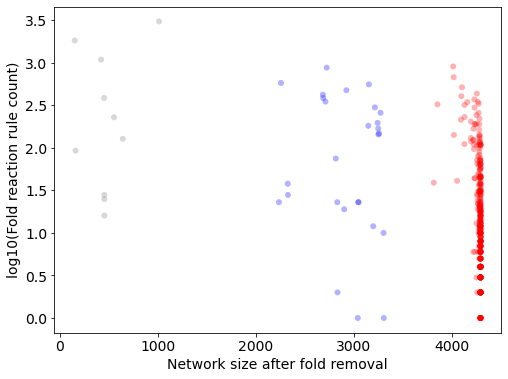

In [308]:
keys, data1, data2 = todata(group1minus10ns, x2rulesNum)
keys, data3, data4 = todata(groupTwo2ns, x2rulesNum)
keys, data5, data6 = todata(xgroup2sub1500, x2rulesNum)

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='gray', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size after fold removal', fontsize=14)
ax.set_ylabel('log10(Fold reaction rule count)', fontsize=14)
plt.tick_params(labelsize=14)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# Boxplot: Phyletic Disribution Scores of Group1 vs. Group2

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_4997/1694913714.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


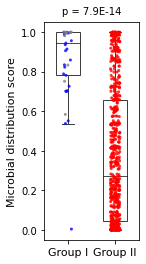

In [177]:
keys, data1, data2 = todata(xgroup2ds_ab, groupOne2ns)
keys, data3, data4 = todata(xgroup2ds_ab, groupTwo2ns)
keys, data5, data6 = todata(xgroup2ds_ab, xgroup2sub1500)

group1ds = np.array(data1)
group2ds = np.array(data3)
first10ds = np.array(data5)
group1minus10ds = np.array(list(set(data1) - set(data5)))

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.8)
colors = ['gray', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.8)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.1E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Microbial distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2_first10.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# "Fold Complexity" of cpds
- cpd x requires 'at least' n folds
- cpd x is 'gated by' n folds

In [16]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

In [9]:
cpd2req_folds = {}
for cpd in list(loo['2002'].cpds_folditer.keys()):
    req_folds = []
    for x in xgroup2ns.keys():
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':
            req_folds.append(x)
    cpd2req_folds[cpd] = req_folds

In [15]:
for cpd, folds in cpd2req_folds.items():
    print(len(folds), cpd, cpd2name[cpd])

0 C00012 Peptide
0 C00161 2-Oxo acid
0 C00311 Isocitrate
0 C00038 Zinc cation
0 C14818 Fe2+
0 C00149 (S)-Malate
0 C00058 Formate
0 C19609 Nickel(2+)
0 C00070 Copper
0 C00175 Cobalt ion
0 Z00069 Divalent Metal (M2)
0 Z00064 Molybdenum
0 C00071 Aldehyde
0 Z00067 3Fe4S
0 C00026 2-Oxoglutarate
0 C19806 Propane-1,2,3-tricarboxylate
396 C00034 Manganese
0 Z00015 Iron
0 C00122 Fumarate
396 Z00020 Generic FeS Cluster
0 C00001 H2O
0 C00036 Oxaloacetate
0 Z00002 4Fe4S
0 Z00070 Copper
0 C00041 L-Alanine
0 C00022 Pyruvate
0 C00030 Reduced acceptor
0 C00042 Succinate
0 C01732 Mesaconate
0 C00049 L-Aspartate
0 Z00060 Monovalent Metal (M1)
0 Z00033 Sodium
0 C00407 L-Isoleucine
0 C00417 cis-Aconitate
0 C00009 Orthophosphate
0 C00209 Oxalate
0 C00123 L-Leucine
0 Z00054 Zinc
0 C00069 Alcohol
0 C01330 Sodium cation
0 Z00030 Mn
0 C00288 HCO3-
0 Z00055 Calcium
0 C00011 CO2
0 Z00053 Tungsten
0 C20679 Tungstate
0 C00238 Potassium cation
0 C00283 Hydrogen sulfide
396 C00050 Metal
0 C01335 ROH
0 C00037 Glycine

40 C05418 Cholesterol-5beta,6beta-epoxide
7 C03124 beta-L-Aspartylhydroxamate
10 C03273 5-Oxopentanoate
13 C15857 9,9'-dicis-zeta-Carotene
37 C03986 3-Hydroxy-4-methylanthranilate
28 C11831 Divinylprotochlorophyllide
10 C02333 Xanthopterin-B2
24 C21672 Ornithine lipid
13 C15990 1L-myo-Inositol 1,2,3,4,6-pentakisphosphate
13 C09898 alpha-Terpinene
24 C12348 3,5,7,9,11,13,15-Heptaoxo-hexadecanoyl-[acp]
14 C20158 (13E)-Labda-7,13-dien-15-ol
17 C12629 Isoswertisin 2''-rhamnoside
25 C05754 trans-Dec-2-enoyl-[acp]
41 C14044 C25-Allenic-apo-aldehyde
12 C00235 Dimethylallyl diphosphate
7 C00802 Oxalureate
18 C02083 Styrene oxide
13 C22109 Hydropyrenol
10 C06419 D-Histidine
17 C01438 Methane
39 C03910 (24R,24(1)R)-Fucosterol epoxide
10 C17263 2-Alkylmalic acid
2 C00117 D-Ribose 5-phosphate
13 C21676 (2S,3R,6S,9S)-(-)-Protoillud-7-ene
3 C05226 N-Carbamoyl-D-amino acid
11 C22024 Staphylopine
23 C18006 gamma-L-Glutamyl-[acp]
13 C00255 Riboflavin
24 C22142 Cyclo(L-Trp-L-Phe)
41 C21477 1-Hydroxyphen

KeyError: 'MeCobamineCofactor'

In [247]:
cpd2req_foldsNum = {key:len(values) for key, values in cpd2req_folds.items()}

In [248]:
len(cpd2req_foldsNum)  # 4294 == vanilla + 3?

4294

In [24]:
max(cpd2req_foldsNum.values())

396

In [28]:
# it's the 3 compounds!!
# because these cpds never appear

for cpd, num in cpd2req_foldsNum.items():
    if num > 100:
        print(cpd, cpd2name[cpd])

C00034 Manganese
Z00020 Generic FeS Cluster
C00050 Metal


In [249]:
cpd2req_foldsNum.pop('C00034')
cpd2req_foldsNum.pop('Z00020')
cpd2req_foldsNum.pop('C00050')

396

In [250]:
len(cpd2req_foldsNum)  # 4291 == vanilla

4291

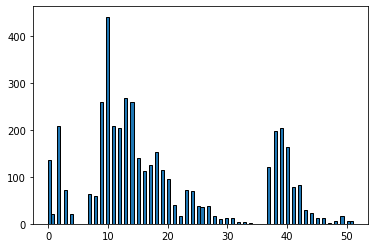

In [36]:
plt.hist(cpd2req_foldsNum.values(), bins=100, edgecolor='k')
plt.show()

In [38]:
cpd2req_foldsNum['C00007']

37

In [92]:
plus37 = []
for cpd, num in cpd2req_foldsNum.items():
    if num > 36:
        print(num, cpd, cpd2name.get(cpd, 'N/A'))
        plus37.append(cpd)

41 C16368 Pelargonidin 3-(6-p-coumaroyl)glucoside
37 C21124 IPA imine
40 C05551 Penicillin G
39 C00778 Rhodopsin
38 C11818 (R)-Canadine
37 C03666 2-Carboxy-cis,cis-muconate
38 C21079 5'-Dehydrouridine
39 C01617 Taxifolin
49 C15682 Mycinamicin VI
40 C10020 Apigenin 7-(6''-malonylglucoside)
41 C03281 Kanamycin A 3'-phosphate
40 C20399 Pentalenolactone D
41 C12647 Salvianin
40 C00599 Cholest-4-en-3-one
39 C00777 Retinoate
39 C01802 Desmosterol
38 C06533 Papaverine
38 C05653 Formylanthranilate
40 C22168 Meleagrin
42 C16355 7-Methyluric acid
42 C00722 Epoxide
39 C00788 L-Adrenaline
41 C21259 Nebramine
39 C01156 Quercetin 3,4'-bissulfate
44 C07354 (7S,8S)-DiHODE
40 C20981 5,10-Dihydrophenazine-1-carboxylate
38 C00974 Dihydrokaempferol
38 C20554 Paspalinine
42 C21192 Epoxypheophorbide a
37 C11631 9-Riburonosylhypoxanthine
38 C21369 N-(2-Methylpropanyl)hydroxylamine
38 C00519 Hypotaurine
38 C21825 9beta-Pimara-7,15-diene-3beta-ol
41 C19865 Soyasaponin III
40 C20398 Pentalenolactone E
37 C15603

38 C03198 (S)-4-Hydroxymandelate
38 C08312 Psilocin
38 C15502 3-Epihydroxy-2'-deoxymugineic acid
38 C21762 4-Hydroxytryptamine
39 C02075 Retinyl ester
41 C02050 Linoleoyl-CoA
41 C08588 Crocetin
40 C11904 Dihydromethanophenazine
37 C15497 1-(beta-D-Ribofuranosyl)-1,4-dihydronicotinamide
37 C20396 Methylphosphonate
41 C21258 4'-Oxonebramine
38 C02220 2-Aminomuconate
39 C21875 Aurachin A
38 C03648 cis-3,4-Leucopelargonidin
39 C22115 4alpha-Formyl-4beta,14alpha-dimethyl-9beta,19-cyclo-5alpha-ergost-24(24(1))-en-3beta-ol
39 C00376 Retinal
39 C20545 Terpendole J
39 C02141 Cycloeucalenol
41 C16162 (9Z,12Z,15Z)-Octadecatrienoyl-CoA
42 C04555 Dehydroepiandrosterone sulfate
39 C21801 (+)-Demethylpiperitol
40 C20402 Neopentalenolactone D
39 C22114 4alpha-(Hydroxymethyl)-4beta,14alpha-dimethyl-9beta,19-cyclo-5alpha-ergost-24(24(1))-en-3beta-ol
40 C17946 Carboxyphosphonopyruvate
38 C22010 3beta-Hydroxy-15,16-epoxydolabrene
38 C17757 2-Descarboxy-betanidin
37 C17262 S-Alkyl-thiohydroximate
38 C05570

40 C22113 16alpha-Hydroxy-beta-amyrin
40 C12632 Luteolin 7-O-[beta-D-glucuronosyl-(1->2)-beta-D-glucuronide]
39 C21126 K-252c
37 C04584 6-Imino-5-oxocyclohexa-1,3-dienecarboxylate
39 C06186 Arbutin
40 C21411 (1R,10aS)-1,4,10,10a-Tetrahydrophenazine-1-carboxylate
43 C07189 2-Hydroxyacetophenone
39 C20249 (Z)-3-Peroxyaminoacrylate
38 C21778 Norbaeocystin
38 C17349 Guanidine
42 C16163 (6Z,9Z,12Z,15Z)-Octadecatetraenoyl-CoA
40 C21476 Phenazine
38 C12325 3,5-Dihydroxyphenylglyoxylate
42 C03917 Dihydrotestosterone
38 C02674 Deoxyribonolactone
40 C05648 5-Hydroxy-N-formylkynurenine
39 C09727 (-)-Epicatechin
38 C05527 3-Sulfinylpyruvate
39 C04608 Apigenin 7-O-beta-D-glucoside
40 C19763 Soyasapogenol B 3-O-D-glucuronide
45 C16310 3-Hexenal
40 C05651 5-Hydroxykynurenine
39 C02470 Xanthurenic acid
41 C05584 3-Methoxy-4-hydroxymandelate
38 C01036 4-Maleylacetoacetate
37 C16357 3-Methylxanthine
39 C21619 (2-Hydroxy-1H-indol-3-yl)acetate
40 C20350 2'-Deamino-2'-hydroxyneamine


In [93]:
len(plus37)

962

In [62]:
len(divider_cpds_g1g2)

118

In [61]:
# (list of cpds that 'require' 37+ folds) INCLUDES g1g2 dividers
# these 962 cpds are likely 'post-O2 compounds'

len(set(plus37) & set(divider_cpds_g1g2))

118

In [63]:
aa = ['C00017', 'C00037', 'C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']
for c in aa:
    print(c, cpd2name[c], cpd2req_foldsNum[c])

C00017 Protein 23
C00037 Glycine 0
C00077 L-Ornithine 8
C00041 L-Alanine 0
C00097 L-Cysteine 2
C00049 L-Aspartate 0
C00025 L-Glutamate 0
C00079 L-Phenylalanine 18
C00135 L-Histidine 10
C00407 L-Isoleucine 0
C00047 L-Lysine 12
C00123 L-Leucine 0
C00073 L-Methionine 9
C00152 L-Asparagine 0
C00148 L-Proline 0
C00064 L-Glutamine 2
C00062 L-Arginine 11
C00065 L-Serine 0
C00188 L-Threonine 0
C00183 L-Valine 0
C00078 L-Tryptophan 12
C00082 L-Tyrosine 17


In [ ]:
# Phe > Tyr > Trp = Lys > Arg > His > Met > Orn > Glu = Cys
# Asp is not in seed, but requires no fold

## compare with O2 ablation

In [71]:
O2ablate = {'C00668', 'C15930', 'C03401', 'C12838', 'C00763', 'C01040', 'C16776', 'C05766', 'C00042', 'C11811', 'C11516', 'C00683', 'C06222', 'C11881', 'C22162', 'C18337', 'C04471', 'C18049', 'C01126', 'C22204', 'C22110', 'C19960', 'C15767', 'C20198', 'C16597', 'C02247', 'C09819', 'C15563', 'C03296', 'C16155', 'C05688', 'C06002', 'C04570', 'C20925', 'C20272', 'C00808', 'C16116', 'C22029', 'C02991', 'C18054', 'C00209', 'C02997', 'C02306', 'C01041', 'Z00038', 'C18052', 'C00673', 'C00583', 'C21306', 'C02067', 'C00637', 'C02637', 'C00596', 'C04807', 'C06016', 'C12125', 'C09723', 'C20375', 'C01077', 'C22259', 'C09844', 'C16622', 'C19971', 'C00438', 'C06083', 'C00148', 'C03722', 'C00168', 'C00379', 'C02291', 'C01755', 'C00162', 'C22174', 'C12126', 'C21343', 'C03933', 'C00502', 'C05931', 'C00080', 'C03141', 'C15814', 'C01613', 'C21701', 'C22320', 'C20904', 'C21607', 'C18872', 'C04180', 'C09629', 'C05711', 'C15895', 'C02713', 'C22288', 'C02876', 'C17582', 'C02944', 'C00065', 'C01444', 'Z00039', 'Z00024', 'C21889', 'C01898', 'C00139', 'C02666', 'C10208', 'C04058', 'C06135', 'C20156', 'C20178', 'C04484', 'Z00025', 'Z00013', 'C15585', 'C03659', 'C00692', 'C21452', 'C18223', 'C02953', 'Z00004', 'C05575', 'C22039', 'C21018', 'C06124', 'C22058', 'C00353', 'C00283', 'C14819', 'C00204', 'C06442', 'C06090', 'C00540', 'C18326', 'C00183', 'C00286', 'C11529', 'C11879', 'C07838', 'C18151', 'C03964', 'C15524', 'C19737', 'C21725', 'C02469', 'C00097', 'C16519', 'C20159', 'C02462', 'C21643', 'C00084', 'C02734', 'C17401', 'C00063', 'C03030', 'C02463', 'C08733', 'C19878', 'C19946', 'C21617', 'C04520', 'C01620', 'C19929', 'C20395', 'C14818', 'C16069', 'C22338', 'C18063', 'C06193', 'C22248', 'C21453', 'C00664', 'C06201', 'C06057', 'C05670', 'C00800', 'C20163', 'C06030', 'C17750', 'C16702', 'C21687', 'C01186', 'C22450', 'C00479', 'C06307', 'C02480', 'C02218', 'C01746', 'C20576', 'C01419', 'C01250', 'C20621', 'C19879', 'C20746', 'C02133', 'C06306', 'C15892', 'C01093', 'C04509', 'C17749', 'C11354', 'C03738', 'C00194', 'C20636', 'C16698', 'C20172', 'C21684', 'C00137', 'C05710', 'C01408', 'C05777', 'C20890', 'C20657', 'C00852', 'C09822', 'C22165', 'C02989', 'C00174', 'C20455', 'C07335', 'C02930', 'C16848', 'C03993', 'C21613', 'C21441', 'C03589', 'C01727', 'C05528', 'C05422', 'C01450', 'C04544', 'C19881', 'C05427', 'C17228', 'C01079', 'C00091', 'C21606', 'C05745', 'C04002', 'C05383', 'C11348', 'C04053', 'C05759', 'C12088', 'C17745', 'C05005', 'C00785', 'C17223', 'C21681', 'C05999', 'C02265', 'C04033', 'C01213', 'C18331', 'C02512', 'C00681', 'C00166', 'C10452', 'C20923', 'C01678', 'C05572', 'C00120', 'C01101', 'C00536', 'C01242', 'C04823', 'C19708', 'C17432', 'C20435', 'C06440', 'C01113', 'C00060', 'C17467', 'C11928', 'C02686', 'C04501', 'C19814', 'C06062', 'C15668', 'C11338', 'C06076', 'C04236', 'C00199', 'C04170', 'C05752', 'C11909', 'C05587', 'C05823', 'C05361', 'C05226', 'C00198', 'C00021', 'C06102', 'C01468', 'C06232', 'C22209', 'C21091', 'C13051', 'C11911', 'C03272', 'C04352', 'C00641', 'C01989', 'C22318', 'C01019', 'C07083', 'C00644', 'C19961', 'C05399', 'C03064', 'C19152', 'C18006', 'C06891', 'C04346', 'C11355', 'C04895', 'C17741', 'C06507', 'C18061', 'C05379', 'C03771', 'C17263', 'C06394', 'C08511', 'C06054', 'C01194', 'C02222', 'C05974', 'C16159', 'C01118', 'C17434', 'C04773', 'C05684', 'C06231', 'C00498', 'C02051', 'C00205', 'C21621', 'C00218', 'C06033', 'C00163', 'C18172', 'C06031', 'C12355', 'C04327', 'C19740', 'C03453', 'C00511', 'C09750', 'C09541', 'C03090', 'C06075', 'C02715', 'C05668', 'C05718', 'C16405', 'C03223', 'C01877', 'C02837', 'C01467', 'C11929', 'C04115', 'C16827', 'C00177', 'C19908', 'C20267', 'C05582', 'C02333', 'C21287', 'C11546', 'C02962', 'C13378', 'C03189', 'C18911', 'C00169', 'C00134', 'C00506', 'C04582', 'C05276', 'C01432', 'C11472', 'C14463', 'C09817', 'C14144', 'C02273', 'C02983', 'C00826', 'C05702', 'C00320', 'C09814', 'C11927', 'C00203', 'C21689', 'C02209', 'C16242', 'C00263', 'C01182', 'C12318', 'C03034', 'C00512', 'C01268', 'C06180', 'C05770', 'C22246', 'C20680', 'C20562', 'C02385', 'C00016', 'C11993', 'C05758', 'C01152', 'C20830', 'C21265', 'C19703', 'C05893', 'C01762', 'C20682', 'C18235', 'C05853', 'C01847', 'C00079', 'C00685', 'C11515', 'C16588', 'C11389', 'C06356', 'C21680', 'C21262', 'C01832', 'C01185', 'C00526', 'C05703', 'C04246', 'C00109', 'C21437', 'C20712', 'C01582', 'C10497', 'C06011', 'C05707', 'C06159', 'C06714', 'C20620', 'C05176', 'C02376', 'C01087', 'C05840', 'C01029', 'C00441', 'C00242', 'C20860', 'C05616', 'C16186', 'C00503', 'C01804', 'C06408', 'C00249', 'C05945', 'Z00041', 'C07044', 'C12108', 'C19669', 'C06125', 'C20961', 'C05378', 'C05773', 'C12366', 'C00409', 'C21715', 'C04233', 'C00858', 'C16276', 'C19907', 'C10772', 'C05411', 'C06018', 'C01035', 'C09820', 'C02630', 'C21272', 'Z00007', 'C06132', 'C01300', 'C06029', 'C01401', 'C00323', 'C04290', 'C05929', 'C06224', 'C06111', 'C18021', 'C08371', 'C16849', 'C01616', 'C00270', 'C06181', 'C05231', 'C00921', 'C05772', 'C00791', 'C00309', 'C19794', 'C21153', 'C02926', 'C06359', 'C22031', 'C05574', 'C01026', 'C11496', 'C20276', 'C20270', 'C06423', 'C04272', 'C05261', 'C18026', 'C12481', 'C15867', 'C06372', 'C00264', 'C20433', 'C03516', 'C18232', 'C04248', 'C08325', 'C02656', 'C11502', 'C04216', 'C05705', 'C03785', 'C00004', 'C02582', 'C02927', 'C11907', 'C21015', 'C05985', 'C00546', 'C04938', 'C21659', 'C22230', 'C22164', 'C20622', 'C12317', 'C04332', 'C03172', 'C16666', 'C22272', 'C05981', 'C04282', 'C20922', 'C07836', 'C00750', 'C05751', 'C05306', 'C00266', 'C00587', 'Z00015', 'C01290', 'C05350', 'C18314', 'C22024', 'C10641', 'C02015', 'C00123', 'C00116', 'C22151', 'C09762', 'C20062', 'C15976', 'C04637', 'C04359', 'C00315', 'C15972', 'C22237', 'C01368', 'C22299', 'C00429', 'C11437', 'C00450', 'C22340', 'C03373', 'C15998', 'Z00026', 'C22008', 'C20729', 'C09099', 'C06505', 'C10447', 'C04137', 'C02083', 'C09810', 'C03372', 'C21486', 'C16593', 'C00860', 'C21720', 'C17742', 'C06153', 'C02835', 'C20184', 'C11890', 'C02442', 'C00904', 'C06509', 'C00068', 'C16221', 'C21645', 'C01080', 'C11393', 'C03848', 'C01594', 'C02631', 'C02084', 'C00349', 'C02170', 'C00755', 'C00059', 'C01596', 'C22187', 'C10517', 'C21255', 'C05266', 'C06037', 'C00920', 'C15567', 'C00222', 'C00003', 'C00167', 'C21507', 'C21354', 'C00239', 'C22363', 'C07303', 'C22236', 'C20386', 'C00372', 'C11554', 'C18035', 'C16829', 'C00252', 'C18239', 'C01222', 'C12214', 'C01359', 'C01230', 'C00488', 'C03153', 'C01291', 'Z00028', 'C12213', 'C22154', 'C15548', 'C05516', 'C04227', 'C10945', 'C11544', 'C01108', 'C01825', 'C05568', 'C21169', 'C03479', 'C19781', 'C03117', 'C04630', 'C19736', 'C05526', 'C15556', 'C00319', 'C06129', 'C20776', 'C18050', 'C03688', 'C12628', 'Z00063', 'C18168', 'Z00016', 'C00124', 'C05512', 'C11822', 'C05324', 'C00575', 'C00136', 'C02444', 'C02612', 'C02714', 'C00181', 'C01346', 'C08276', 'C00556', 'C06074', 'C00552', 'Z00070', 'C20082', 'C22260', 'C11930', 'C05552', 'C19880', 'C11557', 'C03494', 'C17367', 'C01489', 'C13309', 'C01742', 'C09825', 'C03871', 'C06322', 'C01120', 'C01533', 'C05835', 'C04006', 'C02000', 'C16390', 'C12270', 'C05673', 'C00476', 'C11894', 'C20902', 'C03576', 'C03167', 'C17327', 'C16470', 'C01188', 'C16737', 'C00439', 'C22251', 'C20888', 'C00092', 'C00388', 'C18338', 'C04540', 'C00491', 'C00531', 'C02572', 'C21450', 'C16028', 'C11925', 'C21294', 'C22451', 'C05809', 'Z00017', 'C11039', 'C00085', 'C04259', 'C05340', 'C20617', 'C05341', 'C00618', 'C06194', 'C21913', 'C17205', 'C11916', 'C18334', 'C06000', 'C02557', 'C00322', 'C15861', 'C03187', 'C01487', 'C05338', 'C22045', 'C04874', 'C00966', 'C22108', 'C03584', 'C04574', 'C00217', 'C05749', 'C04939', 'C00879', 'C21028', 'C00633', 'C22233', 'C01502', 'C21674', 'C02716', 'C01063', 'C16850', 'C00827', 'C00346', 'C17234', 'C06241', 'C02331', 'C12621', 'C09663', 'C19815', 'C05747', 'C03680', 'C18126', 'C06655', 'C01500', 'C17215', 'C04856', 'C00188', 'C05824', 'C20121', 'C02887', 'C03546', 'C11514', 'C11877', 'C01944', 'C20966', 'C19685', 'C18032', 'C07481', 'C18070', 'C19754', 'C01277', 'C17759', 'C18226', 'C22182', 'C12106', 'C11920', 'C21676', 'C02723', 'C02918', 'C04431', 'C03459', 'C10906', 'C06561', 'C01612', 'C19761', 'C09209', 'C21679', 'C03979', 'C02576', 'C04911', 'C20962', 'C20434', 'C05678', 'C05345', 'C21630', 'C06370', 'C00126', 'C01772', 'C06089', 'C21393', 'C21654', 'C00448', 'C00944', 'Z00006', 'C01367', 'C05763', 'C22074', 'C05274', 'C18902', 'C05855', 'C21694', 'C21181', 'C13508', 'C06021', 'C02362', 'C02232', 'C21261', 'C19673', 'C19816', 'C20954', 'C00032', 'C02231', 'C20654', 'C14179', 'C06718', 'C01289', 'C03684', 'C00688', 'C04916', 'C03082', 'C21403', 'C05629', 'C20582', 'C00880', 'C17941', 'C21116', 'C04454', 'C21711', 'C20498', 'C02763', 'C22255', 'C12348', 'C05898', 'C04767', 'C17592', 'C06217', 'C05596', 'C00118', 'C20896', 'C05513', 'C06203', 'C22044', 'C04062', 'C15700', 'C19694', 'C04808', 'C00813', 'C04020', 'C05131', 'C20479', 'C22181', 'MeCobamineCofactor', 'C05158', 'C19702', 'C17214', 'C18034', 'C03115', 'C00234', 'C16594', 'C02226', 'C00262', 'C03289', 'C05334', 'C17530', 'C21877', 'C00244', 'C05761', 'C01302', 'C19806', 'C11499', 'C06376', 'C02489', 'C15874', 'C21603', 'C01402', 'C19683', 'C20374', 'C01131', 'C03341', 'C00811', 'C16190', 'C15926', 'C21491', 'C00383', 'C00672', 'C05938', 'C00455', 'C04702', 'C01071', 'C20614', 'C20411', 'C05672', 'C16521', 'C03961', 'C00630', 'C21523', 'C04045', 'C05699', 'C22055', 'C00127', 'C20353', 'C00862', 'C05998', 'C16884', 'C03989', 'C00847', 'C00640', 'C19871', 'C03087', 'C00049', 'C00655', 'C04089', 'C22359', 'C00191', 'C12356', 'C05686', 'C20447', 'C03996', 'C01161', 'Z00018', 'C16999', 'C06010', 'C04924', 'C00361', 'C16826', 'C20357', 'C09809', 'C11507', 'Z00009', 'C02621', 'C17216', 'C05785', 'C21608', 'C22160', 'C03120', 'C00053', 'Z00022', 'C20710', 'C00601', 'C03885', 'C00515', 'C19755', 'C22155', 'C04734', 'C20953', 'C17701', 'C02993', 'C00165', 'C00855', 'C19834', 'C19756', 'C02183', 'C01998', 'C20559', 'C04197', 'C12629', 'C15974', 'C20911', 'C05265', 'C09900', 'C06603', 'C22347', 'C02488', 'C20742', 'C04633', 'C21107', 'C04877', 'C16238', 'C00558', 'C02344', 'Z00008', 'C01245', 'C16141', 'C04752', 'C02972', 'C18028', 'C18096', 'C22150', 'C20656', 'C20626', 'C00077', 'C03620', 'C04390', 'C07111', 'C22224', 'C01917', 'C00449', 'C02737', 'C06145', 'Z00058', 'C03582', 'C02353', 'C03460', 'C18033', 'C21064', 'C18094', 'C20985', 'C01239', 'C18229', 'C02411', 'C06240', 'C03557', 'C03974', 'C05769', 'C03658', 'C21707', 'C02565', 'C05539', 'C02320', 'C21618', 'C05600', 'C21505', 'C00431', 'C17219', 'C21137', 'C04171', 'C01201', 'C06892', 'C05691', 'C00088', 'C09140', 'C00903', 'C20161', 'C20794', 'C00337', 'C21651', 'C00155', 'C00095', 'C20638', 'C12537', 'C18228', 'C01743', 'C22328', 'C21512', 'C22180', 'C21717', 'C04253', 'C07350', 'C06548', 'C11997', 'C00385', 'C01869', 'C04024', 'C15907', 'C21497', 'C20856', 'C14610', 'Z00001', 'C19852', 'C03703', 'C05264', 'C01352', 'C00559', 'C05270', 'C02703', 'C01137', 'C00312', 'C21686', 'C01659', 'C01068', 'C03741', 'Z00003', 'C20155', 'Z00030', 'C02745', 'C01241', 'C06371', 'C00147', 'C01177', 'C19795', 'C06364', 'C09847', 'C02947', 'C03912', 'C21780', 'C02800', 'C00937', 'C16404', 'C16465', 'C02091', 'C03267', 'C12000', 'C20903', 'Z00047', 'C20955', 'C03652', 'C01286', 'C00299', 'C03345', 'C00375', 'C00424', 'C20775', 'C09811', 'C21087', 'C05731', 'C00751', 'C06746', 'C20681', 'C04549', 'C15813', 'C05359', 'C02004', 'C06355', 'C20764', 'C01114', 'C21675', 'C16461', 'C00582', 'C01046', 'C21289', 'C11545', 'C05275', 'C21616', 'C21873', 'C20959', 'C04896', 'C17366', 'C01083', 'C11539', 'C21350', 'C20646', 'C21129', 'C01146', 'C00570', 'C12354', 'C20798', 'C04015', 'C05979', 'Z00036', 'C00365', 'C02721', 'C21336', 'C04478', 'C00025', 'C12231', 'C19684', 'C03618', 'C21718', 'C01326', 'C03161', 'C06046', 'C03319', 'C20679', 'C16502', 'C18233', 'C00923', 'C00623', 'C20937', 'C00416', 'C00018', 'C02589', 'C00221', 'C19813', 'C19686', 'C22097', 'C11924', 'C20910', 'C03024', 'C11498', 'C01438', 'C02946', 'Z00054', 'C00693', 'C01042', 'C00236', 'C05380', 'C03351', 'C19840', 'C03107', 'C19720', 'C20845', 'C18327', 'C03406', 'C20327', 'C02137', 'C17220', 'C20988', 'C00141', 'C02354', 'Z00032', 'C20969', 'C11542', 'C02266', 'C22176', 'C15684', 'C16930', 'C03493', 'C19760', 'C16814', 'C21670', 'C09614', 'C03124', 'C01288', 'C20963', 'C02315', 'C00333', 'C00233', 'C02939', 'C00392', 'C22360', 'C03291', 'C04677', 'C20480', 'C03519', 'C19674', 'C03393', 'C21068', 'C03058', 'C03838', 'C04225', 'C17744', 'C11880', 'C00061', 'C06399', 'C00099', 'C01235', 'C15886', 'C02405', 'C19845', 'C22101', 'C02741', 'C00514', 'C22279', 'C00394', 'C09332', 'C05753', 'C15943', 'C03656', 'C06311', 'C05123', 'C21408', 'C21284', 'C15486', 'C00226', 'C05412', 'C00296', 'C21030', 'C00294', 'C19817', 'C00357', 'C19682', 'C04639', 'C00492', 'C22261', 'C00482', 'C00179', 'C14145', 'C03428', 'C15888', 'C11556', 'C05825', 'C02253', 'C21430', 'C21673', 'C04376', 'C19823', 'C00024', 'C15991', 'C01096', 'Z00066', 'C03263', 'C02059', 'C00237', 'C12204', 'C01769', 'C01935', 'C06309', 'C03586', 'C04640', 'C00990', 'C03089', 'C02938', 'C01031', 'C16145', 'C22250', 'C06593', 'C20481', 'C11915', 'C06313', 'C06060', 'C20640', 'C21310', 'C00957', 'C03599', 'C04732', 'C00130', 'C21394', 'C01172', 'C02356', 'C06760', 'C19753', 'C16340', 'C01298', 'C04146', 'C01697', 'C00101', 'C15977', 'C06136', 'C03740', 'C05704', 'C05767', 'C01304', 'C21283', 'C15522', 'C00691', 'Z00043', 'C21727', 'C03600', 'C00231', 'C20417', 'C03239', 'C00437', 'C04619', 'C21353', 'C00119', 'C03361', 'C09666', 'C15881', 'C12001', 'C03716', 'C01929', 'C18002', 'C21631', 'C15908', 'C09639', 'C21357', 'C11062', 'C03646', 'C05744', 'C02977', 'C01380', 'C19882', 'C00483', 'C20462', 'C06357', 'C12367', 'C00404', 'C22135', 'C11961', 'C05601', 'Z00031', 'C05662', 'C00156', 'C00741', 'C01765', 'C03415', 'C11998', 'C03483', 'C03221', 'C15651', 'C21312', 'C10454', 'C03539', 'C00857', 'C03623', 'C16217', 'C04882', 'C02199', 'C05269', 'C01219', 'C05358', 'Z00062', 'C02475', 'C22219', 'C05268', 'C02869', 'C01100', 'C00232', 'C17740', 'C00096', 'C04405', 'C04181', 'C00355', 'C21656', 'C20565', 'C04226', 'C22342', 'C00093', 'C17231', 'C16565', 'C02097', 'C01260', 'C18225', 'C21672', 'C05682', 'C02704', 'C04046', 'C16408', 'C09871', 'C02593', 'C11541', 'C00146', 'C07086', 'C12350', 'C22072', 'C04618', 'C18064', 'C00682', 'C20145', 'C00197', 'C22220', 'C02960', 'C09818', 'C06680', 'C00906', 'C22298', 'C03134', 'C19837', 'C11453', 'C20418', 'C01271', 'C22185', 'C21070', 'C21615', 'C22247', 'C00026', 'C21677', 'C20619', 'C20415', 'C20651', 'C19724', 'C02798', 'C11831', 'C00999', 'C02669', 'C19151', 'C07113', 'C03046', 'C02659', 'C03277', 'C05692', 'C03761', 'C12115', 'C03692', 'C17883', 'C00590', 'C05922', 'C05712', 'C11829', 'C05821', 'C01818', 'C00726', 'C22021', 'C15877', 'C21288', 'Z00045', 'C00460', 'C20986', 'C00020', 'C10434', 'C14097', 'C21698', 'C03044', 'C01159', 'C21892', 'C03765', 'C17439', 'C20246', 'C00779', 'C00795', 'C18328', 'C16074', 'C06161', 'C00153', 'C19706', 'C00605', 'C05595', 'C22205', 'C16674', 'C01228', 'C03298', 'C20800', 'C04268', 'C01231', 'C21765', 'C00143', 'C00313', 'C11989', 'C18023', 'C03985', 'C17556', 'C02564', 'C11536', 'C20885', 'C00440', 'C00288', 'C03708', 'C03997', 'C05923', 'C01777', 'C20612', 'C03170', 'C19847', 'C21485', 'C00566', 'C01279', 'C06032', 'C21611', 'C12211', 'C20243', 'C15606', 'C05239', 'C00078', 'C00877', 'C21425', 'C04925', 'C02671', 'C22370', 'C00445', 'C00159', 'C01086', 'C18060', 'C15804', 'C06397', 'C06310', 'C00447', 'C04281', 'C01672', 'C04845', 'C04280', 'C16154', 'C16818', 'C01885', 'C05414', 'C20781', 'C01845', 'C15999', 'C19975', 'C00820', 'C04673', 'C00170', 'C01909', 'C11351', 'C00611', 'C20664', 'C05631', 'C11543', 'C06035', 'C16267', 'C00100', 'C20158', 'C12203', 'C00878', 'C22262', 'C01175', 'C22163', 'C19744', 'C21649', 'C17328', 'C00352', 'C00905', 'Z00005', 'C04655', 'C01860', 'C01051', 'C01745', 'C02627', 'C00422', 'C00125', 'C12215', 'C09806', 'C06104', 'C19797', 'C19609', 'C09898', 'C21383', 'C06304', 'C21017', 'C00963', 'C00823', 'C00129', 'C01073', 'C01586', 'C03851', 'C01335', 'C16222', 'C05946', 'C04164', 'C11435', 'C03868', 'C00366', 'C11912', 'C21429', 'C00466', 'Z00033', 'C06007', 'C01001', 'C00517', 'C06735', 'C01841', 'C20613', 'C16271', 'C21688', 'C00789', 'C01685', 'C02727', 'C02587', 'C05619', 'C09648', 'C00933', 'C13482', 'C06761', 'C17746', 'C00041', 'C00793', 'C22048', 'C12319', 'C01209', 'C02504', 'C04187', 'C00292', 'C00044', 'C20179', 'C22057', 'C17218', 'C05403', 'C12442', 'C16426', 'C00408', 'C02457', 'C00412', 'C02041', 'C20497', 'C01920', 'C20464', 'Z00052', 'C00356', 'C01004', 'C05689', 'C01144', 'C00043', 'C00603', 'C02787', 'C00548', 'C21784', 'C04434', 'C03190', 'C00246', 'C00345', 'C00475', 'C00223', 'C05178', 'C04076', 'C22245', 'C06218', 'C01216', 'C06204', 'C22280', 'C04628', 'C20618', 'C16503', 'C15973', 'C02730', 'C00154', 'C00207', 'C01728', 'C07025', 'C22006', 'C06425', 'C20870', 'C21655', 'C03431', 'C04294', 'C10428', 'C16566', 'C08613', 'C02670', 'C19793', 'C06142', 'C00002', 'Z00053', 'C18333', 'C10783', 'C19787', 'C20968', 'C09827', 'C04462', 'C10905', 'C04881', 'C00804', 'C18904', 'C21448', 'C00216', 'C01623', 'C16401', 'C22157', 'C00206', 'C00977', 'C13050', 'C01121', 'C03248', 'C01170', 'C01857', 'C03943', 'C11497', 'C13952', 'C21073', 'C06131', 'C20181', 'C00268', 'C19791', 'C02718', 'C22329', 'C00463', 'C02964', 'C01959', 'C06044', 'C06717', 'C02979', 'C16590', 'C02532', 'C02917', 'C16690', 'C22218', 'C21355', 'C00975', 'C20644', 'C20724', 'C04244', 'C03752', 'C06020', 'C03819', 'C05690', 'C20486', 'C20668', 'C01604', 'C11506', 'C21730', 'C00533', 'C21007', 'C20811', 'C00935', 'C05837', 'C03676', 'C03739', 'C20175', 'C00577', 'C00052', 'C11922', 'C02147', 'C00386', 'C01739', 'C05610', 'Z00059', 'C03156', 'C03383', 'C00774', 'C22249', 'C10469', 'C02378', 'C03290', 'C05433', 'C04297', 'C00458', 'C00986', 'C22131', 'C00072', 'C21427', 'C18051', 'C11994', 'C15531', 'C22253', 'C05973', 'C00009', 'C20154', 'C06114', 'C03273', 'C17209', 'C01020', 'C01294', 'C01893', 'C06452', 'C18802', 'C21604', 'C16463', 'Z00050', 'C19841', 'C20478', 'C00969', 'C00111', 'C03847', 'C03604', 'C04315', 'C06719', 'C21658', 'C02139', 'C20376', 'C21257', 'C21851', 'C05810', 'C01888', 'C06199', 'C00036', 'C05932', 'C00196', 'C05627', 'Z00027', 'C07277', 'C02048', 'C02115', 'C04613', 'C00740', 'C20275', 'C01508', 'C20251', 'C20579', 'C20934', 'C17352', 'C00508', 'Z00046', 'C01043', 'C03981', 'C19779', 'C03284', 'C06250', 'C00459', 'C03394', 'C21100', 'C01894', 'C05401', 'C04737', 'C15860', 'C19838', 'C06040', 'C00330', 'C04308', 'C02335', 'C01602', 'C19809', 'C03197', 'C02486', 'C01720', 'C20240', 'C00138', 'C00894', 'C04830', 'C04556', 'C04847', 'C04529', 'C06555', 'C16540', 'C19891', 'C01234', 'C00112', 'C22038', 'C00178', 'C00407', 'C00213', 'C09839', 'C06036', 'C22052', 'C03079', 'C00074', 'C09699', 'C05262', 'C21004', 'C20831', 'C02866', 'C11356', 'C01024', 'C00058', 'C11038', 'C20653', 'C22254', 'C04083', 'C05822', 'C00415', 'C03794', 'C00818', 'C22339', 'C22060', 'C16075', 'C00314', 'C06400', 'C22217', 'C20233', 'C03145', 'C01414', 'C02501', 'C04910', 'C00105', 'C00973', 'C20673', 'C00235', 'C11540', 'C04421', 'C03537', 'C19894', 'C05697', 'C00919', 'C04631', 'C11537', 'C06001', 'C06508', 'C00580', 'C05746', 'C06216', 'C19153', 'C16423', 'C22337', 'C12305', 'C19156', 'C02336', 'C06050', 'C06675', 'C19719', 'C00561', 'Z00019', 'C00761', 'C06130', 'C06358', 'C22302', 'C05335', 'C09756', 'C06377', 'C20432', 'C20237', 'C05202', 'C19973', 'C05778', 'C19758', 'C05404', 'C00075', 'C20247', 'C21344', 'C22056', 'C00132', 'C04211', 'C15859', 'C00334', 'C20905', 'C02658', 'C04299', 'C05135', 'C06986', 'C01732', 'C03789', 'C21702', 'C00406', 'C06084', 'C05431', 'C00805', 'C03920', 'C06547', 'C04052', 'C06099', 'C20844', 'C02888', 'C16142', 'C01115', 'C19738', 'C01417', 'C00550', 'C06625', 'C00819', 'C18325', 'C00721', 'C06441', 'C16291', 'C00354', 'C04017', 'C01709', 'C05936', 'C00302', 'C05366', 'C00070', 'C00522', 'C01530', 'C00534', 'C19767', 'C05396', 'C06412', 'C16700', 'C07351', 'C12109', 'C05750', 'C01744', 'C01624', 'C06088', 'C00815', 'C21610', 'C21714', 'Z00037', 'C01384', 'C21117', 'C00942', 'C00051', 'C02646', 'C20180', 'C02427', 'C00214', 'C20378', 'C02753', 'C17224', 'C22293', 'C05989', 'C01008', 'C02642', 'C15900', 'C02535', 'C21729', 'C20804', 'C01801', 'C05755', 'C17222', 'C05332', 'C08650', 'C01747', 'C06379', 'C05172', 'C01075', 'C21170', 'C04724', 'C12142', 'C03375', 'C01081', 'C00989', 'C01007', 'C15914', 'C20690', 'Z00057', 'C00363', 'C22270', 'C00282', 'C00844', 'C05907', 'C06019', 'C05258', 'C02045', 'C05432', 'C22348', 'C03598', 'C20173', 'Z00002', 'C05675', 'C20512', 'C06052', 'C04590', 'C08521', 'C20897', 'C09555', 'C21102', 'C09823', 'C12299', 'C12313', 'C22257', 'C00305', 'C01403', 'C20645', 'C00040', 'C04051', 'C02912', 'C00697', 'C00645', 'C04778', 'C20264', 'C00411', 'C21203', 'C06127', 'C22278', 'C00301', 'C02355', 'C05768', 'C16216', 'C22349', 'C02827', 'C05434', 'C00269', 'C05394', 'C00158', 'C21069', 'C16406', 'C12441', 'C04230', 'C21705', 'C04411', 'C21445', 'C00067', 'C08313', 'C21559', 'C04063', 'C20797', 'C00666', 'C20924', 'C03149', 'C00507', 'C22032', 'C00956', 'C01243', 'C17435', 'C22087', 'C03175', 'C07331', 'C02394', 'C15807', 'C20185', 'C20484', 'C03939', 'C20224', 'Z00067', 'C01904', 'Z00069', 'C21085', 'C03147', 'C00490', 'C01817', 'C17212', 'C21955', 'C00011', 'C00254', 'C05841', 'C16701', 'C05357', 'C15902', 'C05307', 'C00010', 'C18169', 'C00568', 'C02105', 'C20942', 'C00275', 'C01204', 'C06393', 'C02022', 'C05406', 'C16268', 'C18224', 'C05328', 'C05223', 'C15565', 'C18174', 'C00325', 'C18237', 'C21352', 'C11953', 'C02130', 'C00023', 'C00279', 'C17326', 'C15898', 'C18157', 'C21752', 'C19741', 'C01127', 'C00430', 'C19784', 'C04691', 'C04922', 'C21123', 'C03005', 'C06468', 'C15670', 'C19743', 'C00104', 'C11638', 'C20581', 'C11830', 'C00527', 'C00369', 'C00627', 'C16273', 'C04275', 'C16562', 'C06672', 'Z00010', 'C06517', 'Z00011', 'C21473', 'C05783', 'C21307', 'C02591', 'C00082', 'C21653', 'C00012', 'C00090', 'C16424', 'C05797', 'C00185', 'C02076', 'C19745', 'C05116', 'C11538', 'C00250', 'C18048', 'C02305', 'C00113', 'C05839', 'C00489', 'C10443', 'C03790', 'C04593', 'C00251', 'C12107', 'C03160', 'C02569', 'C19935', 'C06337', 'C04438', 'C04899', 'C00227', 'C09183', 'C04611', 'C18069', 'C06398', 'C00380', 'C04730', 'C15979', 'C04330', 'C11926', 'C16583', 'Z00051', 'C00108', 'C22033', 'C03440', 'C21693', 'C02934', 'C00114', 'C03724', 'C03733', 'C01013', 'C05819', 'C19771', 'C22143', 'C07112', 'C04783', 'C01267', 'C06451', 'C17440', 'C11555', 'C05669', 'C22092', 'C19974', 'C01962', 'C22258', 'C00180', 'C05147', 'C00940', 'C01112', 'C00620', 'C16365', 'C00186', 'C04210', 'C21010', 'C00241', 'C04442', 'C00013', 'C01269', 'C16407', 'C00362', 'C03506', 'C21511', 'C06520', 'C22027', 'C15996', 'C19154', 'C05198', 'Z00034', 'C01284', 'C17265', 'C20884', 'C16270', 'C00581', 'C02112', 'C05817', 'C21040', 'C16244', 'C00770', 'C05757', 'C21493', 'C02225', 'Z00044', 'C01092', 'C06126', 'C03313', 'C06723', 'C00772', 'Z00064', 'C20849', 'C02090', 'C21281', 'C00259', 'C05607', 'C22083', 'C20926', 'C07130', 'C01132', 'C06656', 'C11902', 'C04145', 'C04579', 'C07301', 'C03287', 'Z00040', 'C06308', 'C00131', 'C15925', 'C00157', 'C03344', 'C00122', 'C02094', 'C02614', 'C04186', 'C00017', 'C12320', 'C22341', 'C20991', 'C16269', 'C01494', 'C05807', 'C06749', 'C00876', 'C02207', 'C22319', 'C00300', 'C01173', 'C05117', 'C15547', 'C04536', 'C02937', 'C06038', 'C20248', 'C01205', 'C02280', 'C17580', 'C21027', 'C18211', 'C20525', 'C05848', 'C00310', 'C20861', 'C04349', 'Z00029', 'C01147', 'C01788', 'C02949', 'C00469', 'C00984', 'C06105', 'C20242', 'C03003', 'C03387', 'C08734', 'C00436', 'C16255', 'C02452', 'C00135', 'C20834', 'C00037', 'C06202', 'C07305', 'C00360', 'C20560', 'C03114', 'C12456', 'C05127', 'C22085', 'C03395', 'C04148', 'C09902', 'C20410', 'C19679', 'C04563', 'C05375', 'C05533', 'C01142', 'C06503', 'C01682', 'C00267', 'C00342', 'C02657', 'C22297', 'C04377', 'C00029', 'C21735', 'C11850', 'C20345', 'C12208', 'C05715', 'C00028', 'C01005', 'C19846', 'C02214', 'C21710', 'C19836', 'C00794', 'C00378', 'C16241', 'C05281', 'C01274', 'C15857', 'C21395', 'C10453', 'C21781', 'C20174', 'C02527', 'C00671', 'C04512', 'C22043', 'C08737', 'C00474', 'C01037', 'C05723', 'C11387', 'C04851', 'C19818', 'C00081', 'C06149', 'C17010', 'C00538', 'C02119', 'C04016', 'C06103', 'C05730', 'C11382', 'C03033', 'C21716', 'C03495', 'C02880', 'C05901', 'C01197', 'C00680', 'C04575', 'C21285', 'C21099', 'C00152', 'C15910', 'C07118', 'C00924', 'C04209', 'C21113', 'C11521', 'C00636', 'C04287', 'C21008', 'C00748', 'C06305', 'C21914', 'C12321', 'C05620', 'C04573', 'C18152', 'C16143', 'C05400', 'C03906', 'C06762', 'C22144', 'C15806', 'Z00060', 'C06352', 'C20476', 'C22177', 'C00898', 'C00976', 'C06160', 'C00513', 'C00996', 'C05984', 'C21510', 'C00149', 'C03758', 'C21026', 'C21971', 'C03742', 'C16427', 'C03826', 'C04638', 'C01050', 'C17959', 'C01996', 'C18234', 'C03451', 'C12124', 'C19748', 'C01062', 'C05925', 'C04425', 'C01104', 'C02024', 'C05271', 'C06213', 'C18007', 'C03028', 'C15878', 'C00836', 'C00631', 'C20768', 'C00273', 'C17227', 'C18324', 'C05760', 'C01721', 'C20238', 'Z00014', 'C20563', 'C01198', 'C06366', 'C20635', 'C00433', 'C17017', 'C02360', 'C22216', 'C04703', 'C04257', 'C19830', 'C17437', 'C00189', 'C15810', 'C00979', 'C21092', 'C00423', 'C00008', 'C09833', 'C09873', 'C01389', 'C19831', 'C22030', 'C08057', 'C20373', 'C21118', 'C05548', 'C09094', 'C20482', 'C16191', 'C11460', 'C22025', 'C10216', 'C00031', 'C07480', 'C00689', 'C18345', 'C03150', 'C03002', 'C01499', 'C08532', 'C00418', 'C22276', 'C00545', 'C20182', 'C15699', 'C00504', 'Z00048', 'C18799', 'C02237', 'C04674', 'C00493', 'C20895', 'C05676', 'C00684', 'C05756', 'C05608', 'C11511', 'C05838', 'C22161', 'C17226', 'C16358', 'C05928', 'C05598', 'C17355', 'C18245', 'C00083', 'C20359', 'C05413', 'C02426', 'C00509', 'C04022', 'C04092', 'C02013', 'C04534', 'C09815', 'C06028', 'C15485', 'C03078', 'C01412', 'C06051', 'C02710', 'C05402', 'C16469', 'C21351', 'C00030', 'C11933', 'C17018', 'C01424', 'C03508', 'C02647', 'C00562', 'C18321', 'C20253', 'C05644', 'C00521', 'Z00012', 'C00343', 'C21506', 'C09684', 'C19725', 'C21695', 'C01566', 'C03062', 'C21709', 'C02330', 'C17581', 'C03063', 'C19714', 'C00140', 'C06510', 'C20277', 'C20239', 'C16417', 'C00542', 'C01218', 'C11910', 'C16775', 'C06148', 'C19972', 'C06893', 'C04302', 'C09812', 'C22053', 'C04884', 'C00184', 'C21585', 'C00006', 'C12210', 'C15879', 'C16144', 'C20372', 'C19747', 'C04713', 'C03427', 'C00884', 'C00073', 'C05263', 'C00087', 'C07447', 'C10287', 'C06430', 'C16488', 'C01102', 'C19675', 'C21640', 'C21094', 'C04079', 'C16286', 'C17558', 'C04088', 'C02895', 'C00038', 'C01134', 'C16416', 'C22075', 'C22186', 'C00846', 'C21706', 'C12324', 'C05775', 'C01328', 'C00055', 'C02717', 'C13425', 'C22158', 'C16352', 'C02985', 'C15685', 'C11832', 'C01934', 'C01097', 'C10478', 'C01372', 'C04641', 'C05430', 'C04832', 'C02431', 'C03972', 'C04419', 'C00331', 'C17264', 'C00941', 'C03354', 'C04488', 'C20258', 'C20983', 'C05748', 'C21835', 'C01190', 'C00887', 'C21764', 'C00327', 'C06055', 'C09789', 'C21016', 'C01984', 'C21175', 'C03135', 'C20940', 'C18797', 'C00086', 'C00332', 'C22102', 'C00015', 'C00151', 'C20772', 'C19947', 'C12092', 'C03561', 'C05681', 'C12323', 'C22203', 'C00943', 'C01094', 'C05665', 'C06042', 'C00161', 'C06006', 'C20412', 'C02295', 'C01157', 'C05267', 'C04348', 'C22277', 'C06432', 'C20190', 'C06473', 'C06419', 'C06365', 'Z00042', 'C21726', 'C02244', 'C20162', 'C00272', 'C00064', 'C09654', 'C17277', 'C04494', 'C06772', 'C05942', 'C20889', 'C16489', 'C18330', 'C11526', 'C22132', 'C01924', 'C04927', 'C21700', 'C00307', 'C02761', 'C07478', 'C10833', 'C15911', 'C00208', 'C01140', 'C19619', 'C00047', 'C01518', 'C21071', 'C16541', 'C02107', 'C20677', 'C22159', 'C16598', 'C20440', 'C06195', 'C18125', 'C16356', 'C15498', 'C04217', 'C01011', 'C21612', 'C01270', 'C05933', 'C19948', 'C00624', 'C00329', 'C22109', 'C20774', 'C04043', 'C21634', 'C11481', 'C16579', 'C11918', 'C20230', 'C02478', 'C00652', 'C01283', 'C08586', 'C05519', 'C21685', 'C20477', 'C16353', 'C05593', 'C03204', 'C09704', 'C04039', 'C00022', 'C00882', 'C00054', 'C11457', 'C02999', 'C00931', 'C01089', 'C16831', 'C21260', 'C20747', 'C00195', 'C05762', 'C18910', 'C01330', 'C00543', 'C15650', 'C16563', 'C21644', 'C08242', 'C01990', 'C03827', 'C02191', 'C01070', 'C20625', 'C04688', 'C01217', 'C05143', 'C00565', 'C04037', 'C01460', 'C18131', 'C00150', 'C00927', 'C03232', 'C01251', 'C00954', 'C06219', 'C20898', 'C05986', 'C03240', 'C16243', 'C11174', 'C05130', 'C11434', 'C15672', 'C04047', 'C00555', 'Z00023', 'C01563', 'C04322', 'C12455', 'C19945', 'C00173', 'C19810', 'C04620', 'C14146', 'C06257', 'C00230', 'C07114', 'C05892', 'C17351', 'C05698', 'C11878', 'C00532', 'C00238', 'C03564', 'C22073', 'C05161', 'C11901', 'C00062', 'C20483', 'C20413', 'C04480', 'C00255', 'C00341', 'Z00061', 'C05259', 'C00885', 'C20848', 'C06056', 'C20424', 'C06771', 'C09813', 'C02693', 'C14830', 'C15532', 'C21609', 'C01455', 'C03712', 'C20829', 'C05273', 'C16466', 'C04415', 'C00175', 'C00576', 'C14899', 'Z00055', 'C03626', 'C00387', 'C20241', 'C01165', 'C15858', 'C00810', 'C02995', 'C00094', 'C00258', 'C20244', 'C15525', 'C00089', 'C07565', 'Z00071', 'Z00035', 'C06121', 'C06182', 'C00971', 'C15527', 'C00497', 'C22350', 'C03660', 'C21728', 'C06554', 'C19742', 'C20773', 'C05385', 'Z00056', 'C00106', 'C20354', 'C01143', 'C03737', 'C03921', 'C03231', 'C05364', 'C19734', 'C20475', 'C05897', 'C04642', 'C00103', 'C00864', 'C00900', 'C00642', 'C05847', 'C21250', 'C09816', 'C21182', 'C00669', 'C00705', 'C21633', 'C20234', 'C08578', 'C14180', 'C22059', 'C00831', 'C00257', 'C01272', 'C22208', 'C01941', 'C19750', 'C02919', 'C10509', 'C16468', 'C17230', 'C00665', 'C06516', 'C02341', 'C17210', 'C05764', 'C05515', 'C00144', 'C00014', 'C21084', 'C22004', 'C00849', 'C07479', 'C01053', 'C00647', 'C01168', 'C20906', 'C11908', 'C02739', 'C20274', 'C22351', 'C21800', 'C07272', 'C20263', 'C03069', 'C20406', 'C16254', 'C05714', 'C00398', 'Z00021', 'C02780', 'C05924', 'C06146', 'C00256', 'C02804', 'C06017', 'C17023', 'C21785', 'C00311', 'C04122', 'C12093', 'C04751', 'C02744', 'C04133', 'C00501', 'C15853', 'C01262', 'C00253', 'C03166', 'C20639', 'C01528', 'C06715', 'C00350', 'C21266', 'C00835', 'C07330', 'C15978', 'C00405', 'C06504', 'C05260', 'C01879', 'C05995', 'C01220', 'C09665', 'C21086', 'C06128', 'C16600', 'C20726', 'C20887', 'C19749', 'C21747', 'C15990', 'C21009', 'C21313', 'C22084', 'C16589', 'C00881', 'C21657', 'C01151', 'C06041', 'C15887', 'C05708', 'C12147', 'C22256', 'C04804', 'C21690', 'C03233', 'C00955', 'C04105', 'C22091', 'C21858', 'C15513', 'C01107', 'C20225', 'C02223', 'C16347', 'C16272', 'C16153', 'C01255', 'C22368', 'C01507', 'C11436', 'C17232', 'C00071', 'C22238', 'C00121', 'C20803', 'C01110', 'C01850', 'C06086', 'C01180', 'C20784', 'C16471', 'C01210', 'C04604', 'C15809', 'C05894', 'C01045', 'C00499', 'C07024', 'C20964', 'C02916', 'C00798', 'C17438', 'C00048', 'C05941', 'C20769', 'C00229', 'C18008', 'C03194', 'C00828', 'C03210', 'C00719', 'C21614', 'C00588', 'C00212', 'C19893', 'C04477', 'C05435', 'C04675', 'C11388', 'C20960', 'C19746', 'C00842', 'C17743', 'C02948', 'C16220', 'C00922', 'C00344', 'C21180', 'C00295', 'C05754', 'C05556', 'C17211', 'C22188', 'C05195', 'C03486', 'C16492', 'C01187', 'C21282', 'C02505', 'C20518', 'C06244', 'C05713', 'C18059', 'C03492', 'C20847', 'C19764', 'C00817', 'C03217', 'C22145', 'C03657', 'C04507', 'C19792', 'C09664', 'C18158', 'C22369', 'C01122', 'C00005', 'C01088', 'C00033', 'C00679', 'C22252', 'C15980', 'C19735', 'C01823', 'C21632', 'C21593', 'C01179', 'C05784', 'C03817', 'C20485', 'C05996', 'C21787', 'C03283', 'C21029', 'C20245', 'C00861', 'C06183', 'C21074', 'C20177', 'C16688', 'C06380', 'C01010', 'C15667', 'C01261', 'C00764', 'C06518', 'C05272', 'C21629', 'C09718', 'C20672', 'C03442', 'C00035', 'C05235', 'C01548', 'C00160', 'C20634', 'C20711', 'C05947', 'C19772', 'C00001', 'C09821', 'C16218', 'C21108', 'C15975', 'C03067', 'C01214', 'C00019', 'C03548', 'C00663', 'C06027', 'C09672', 'C00593', 'C05382', 'C21524', 'C12212', 'C20941', 'C15489', 'C03220', 'C19752', 'C06144', 'C03142', 'C05581', 'C00402', 'C20377', 'C20423', 'C01674', 'C01099', 'C00802', 'C00117', 'C00739', 'C18068', 'C05381', 'C21428', 'C19155', 'C22361', 'C00792', 'C06360', 'C18323', 'C06123', 'C05167', 'C20236', 'C21703', 'C16567', 'C16675', 'C22264', 'C14143', 'C00190', 'C11838', 'C17436', 'C20465', 'C01103', 'C01353', 'C05360', 'C06620', 'C22366', 'C00658', 'C05926', 'C19848', 'C00069', 'C00164', 'C16422', 'C00247', 'C00446', 'C12205', 'C22142', 'C03661', 'C00133', 'C00243', 'C01983', 'C22210', 'C00261', 'C04324', 'C16219', 'C00617', 'C00245', 'C04498', 'C10722', 'C03461', 'C05927', 'C00224', 'C15673', 'C20235', 'C03590', 'C00364', 'C20394', 'C00993', 'C21660', 'C04101', 'C21661', 'C01883', 'C04437', 'C05125', 'C04188', 'C01212', 'C21708', 'C12206', 'C05421', 'C04695', 'C21447', 'C00192', 'C20843', 'C03526', 'C13747', 'C21446', 'C05067', 'C06156', 'C20782', 'C20273', 'C01236', 'C05696', 'C06676', 'C06506', 'C00417', 'C03237', 'C01158', 'C02325'}

In [72]:
full_cpds = set(cpd2req_foldsNum.keys())

In [75]:
# cpds unreachable without O2
post_O2_cpds = full_cpds - O2ablate

In [94]:
len(post_O2_cpds), len(plus37)

(959, 962)

In [78]:
# 959/962 cpds with fold-complexity >= 37 are 'post-O2'
set(plus37) - post_O2_cpds

{'C06675', 'C06676', 'C11481'}

In [79]:
# post_O2_cpds is a subset of set(plus37)
post_O2_cpds - set(plus37)

set()

In [82]:
# fold-comlexity = 37+, but not O2-dependent
for c in ['C06675', 'C06676', 'C11481']:
    print(c, cpd2name[c], cpd2req_foldsNum[c])

C06675 3-Sulfomuconate 37
C06676 4-Sulfolactone 37
C11481 HSO3- 37


## check with average cpd_order in original fold-gated

In [83]:
cpd2coAve_1000 = csv2dict('../data/assets/cpd2co_aveNONE.csv')

In [85]:
c = 'C00007'
print(c, cpd2name[c], cpd2coAve_1000[c])

C00007 Oxygen [304.302, 5.082597367488394]


In [84]:
for c in ['C06675', 'C06676', 'C11481']:
    print(c, cpd2name[c], cpd2coAve_1000[c])

C06675 3-Sulfomuconate [277.615, 3.191359428206113]
C06676 4-Sulfolactone [277.615, 3.191359428206113]
C11481 HSO3- [277.615, 3.191359428206113]


In [91]:
# other high fold-complexity cpds that come before Oxygen (folditer=304)

for c in plus37:
    if cpd2coAve_1000[c][0] < 304:
        print(cpd2req_foldsNum[c], c, cpd2name[c], cpd2coAve_1000[c], c in post_O2_cpds)

# ['C20801', 'C01948', 'C06454', 'C00027'] are 'post-O2' but are discovered before O2...

37 C11481 HSO3- [277.615, 3.191359428206113] False
37 C20801 3-Hydroxy-5-methyl-L-tyrosine [236.208, 17.592519319301598] True
39 C01948 Pentadecanal [170.833, 3.5834495950131613] True
43 C06454 Fosfomycin [237.652, 19.63723239155661] True
37 C06675 3-Sulfomuconate [277.615, 3.191359428206113] False
37 C06676 4-Sulfolactone [277.615, 3.191359428206113] False
37 C00027 Hydrogen peroxide [170.833, 3.5834495950131613] True


### check if ['C20801', 'C01948', 'C06454', 'C00027'] come later with peroxide-fix

In [98]:
# 64 runs
propero = pd.read_csv('pro_pero/pro_pero_cpds_folditer.csv', index_col=0)

In [105]:
for c in ['C00007', 'C20801', 'C01948', 'C06454', 'C00027']:
    print(np.mean(propero.loc[c]), c, cpd2name[c])

# with peroxide-fix, they're all discovered at the same time as O2!

283.90625 C00007 Oxygen
283.90625 C20801 3-Hydroxy-5-methyl-L-tyrosine
283.90625 C01948 Pentadecanal
297.265625 C06454 Fosfomycin
283.90625 C00027 Hydrogen peroxide


In [106]:
for c in ['C02222']:
    print(c, cpd2name[c], cpd2coAve_1000[c])

C02222 2-Maleylacetate [117.511, 3.0119560089748956]


In [107]:
rn2ro_aveNONE = csv2dict('../data/assets/rn2ro_aveNONE.csv')

In [119]:
rn2ro_aveNONE['R05420_v1'], rn2ro_aveNONE['R05394']

([277.615, 3.191359428206113], [277.615, 3.191359428206113])

In [127]:
rn2cpds_SI = csv2dict('../data/assets/rn2cpds_SI.csv')

In [130]:
rns = []
for rn, values in rn2ro_aveNONE.items():
    if values[0] == 277.615:
        if 'C11481' in rn2cpds_SI[rn]:
            print(rn, rn2cpds_SI[rn])
            rns.append(rn)

R07633_v1 {'C11537', 'C11481', 'C00022', 'Z00015'}
R10149_v1 {'C00283', 'Z00025', 'C00320', 'Z00031', 'C05819', 'C00828', 'C11481', 'Z00063'}
R05420_v1 {'C00080', 'C02222', 'C06676', 'Z00054', 'C00001', 'C11481'}
R07634_v1 {'C00014', 'Z00035', 'C00022', 'C00506', 'C00001', 'C11481'}
R10149_v2 {'Z00002', 'C00283', 'Z00025', 'C00320', 'Z00031', 'C05819', 'C00828', 'C11481'}


In [131]:
cs = set()
for rn in rns:
    for c in rn2cpds_SI[rn]:
        cs.add(c)

In [134]:
for c in cs:
    print(c, cpd2coAve_1000[c][0])

C00283 0.0
C00080 0.0
Z00035 11.943
Z00054 0.0
Z00002 0.0
C02222 117.511
C00320 173.057
C00014 0.0
C05819 243.305
C06676 277.615
C00828 277.615
C11481 277.615
Z00063 0.0
Z00015 0.0
Z00025 170.833
C11537 173.057
C00506 173.057
C00001 0.0
Z00031 277.615
C00022 0.0


In [141]:
cpd2name['C00828'], cpd2name['Z00031']

('Menaquinone', 'Molybdopterin', 'Heme', 'Generic FeS')

In [150]:
cpd2name['C05819'], cpd2req_foldsNum['C05819'], cpd2coAve_1000['C05819'][0]

('Menaquinol', 26, 243.305)

In [151]:
cpd2name['C00828'], cpd2req_foldsNum['C00828'], cpd2coAve_1000['C00828'][0]

('Menaquinone', 32, 277.615)

In [159]:
cpd2name['Z00031'], cpd2req_foldsNum['Z00031'], cpd2coAve_1000['Z00031'][0]

('Molybdopterin', 25, 277.615)

In [147]:
cpd2req_foldsNum['C02222']

10

In [153]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')

In [157]:
rn2rules['R10149_v1']

{frozenset({'1', '1001', '2003', '205', '5069'})}

In [158]:
for x in {'1001', '5069', '2003', '1', '205'}:
    print(x2foAveNONE[x])

257.559
238.807
6.511
3.0
45.412


## fold-complexity of reactions?

In [172]:
rn2def_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2rev = csv2dict('../data/assets/rn2reversible.csv')

In [173]:
rn2def_SI['R10149_v1'], rn2rev[rn]

('C11481 + C00283 + C00828 + Z00025 + Z00063 + Z00031 => C00320 + C05819 + Z00025 + Z00063 + Z00031',
 True)

In [175]:
# 'R10149_v1'
rn = 'R10149_v1'
folds = set()
for c in ['C00320', 'C05819', 'Z00025', 'Z00063', 'Z00031']:
    print(len(cpd2req_folds[c]), c, cpd2req_folds[c])
    for fold in cpd2req_folds[c]:
        folds.add(fold)

10 C00320 ['2005', '4952', '325', '2002', '602', '218', '304', '206', '4953', '2007']
26 C05819 ['2005', '4952', '325', '2003', '2002', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '7501', '7579', '2007', '297', '327', '141', '2492']
14 Z00025 ['2005', '4952', '325', '3016', '2003', '2002', '7523', '602', '218', '206', '4953', '7577', '2007', '330']
0 Z00063 []
25 Z00031 ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '218', '2004', '304', '206', '4953', '1', '7577', '7501', '7541', '2007', '253', '7544', '297', '2492']


In [176]:
len(folds)

34

In [178]:
len(folds | {'1001', '5069', '2003', '1', '205'})

37

# fold-complexity of key cpds

In [180]:
# from pre-expansion
cpds1 = ['Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

# from vanilla (+ FMN, AcetylCoA, isopentenyl diphosphate, oxygen)
cpds2 = ['C00007','C00024','C00061','C00129','Z00014', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009']

In [181]:
for c in cpds1:
    print(c, cpd2name[c], cpd2req_foldsNum[c])

Z00035 PLP 2
C00002 ATP 7
C00004 NADH 9
C00019 S-Adenosyl-L-methionine 9
C00010 CoA 10
C00016 FAD 13
Z00047 Thiamine diphosphate 9
Z00009 Cobalamin 24


In [182]:
for c in cpds2:
    print(c, cpd2name[c], cpd2req_foldsNum[c])

C00007 Oxygen 37
C00024 Acetyl-CoA 10
C00061 FMN 13
C00129 Isopentenyl diphosphate 12
Z00014 FMN 13
Z00035 PLP 2
C00002 ATP 7
C00004 NADH 9
C00019 S-Adenosyl-L-methionine 9
C00010 CoA 10
C00016 FAD 13
Z00047 Thiamine diphosphate 9
Z00009 Cobalamin 24


In [ ]:
# Oxygen >> Cobalamin >> FAD = FMN > IPP > Acetyl-CoA = CoA > ThDP = SAM = NADH > ATP > PLP

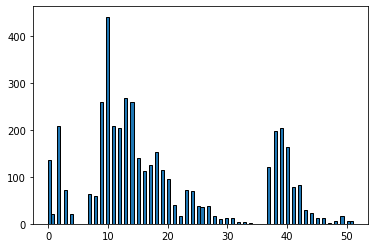

In [186]:
plt.hist(cpd2req_foldsNum.values(), bins=100, edgecolor='k')
plt.show()

# check the architecture

In [188]:
x2arc = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')
x2class = csv2dict('../data/assets/xgroup2/xgroup2class.csv')

In [192]:
classes = {'a/b':[], 'a+b':[], 'alpha':[], 'beta':[], 'a/b':[], 'mixed':[], 'other':[]}
for x in cpd2req_folds['C00007']:
    classes[x2class[x]].append(x)

In [194]:
for cl, folds in classes.items():
    print(cl, len(folds))

# 70% of '37 folds to O2' are a/b or a+b

a/b 13
a+b 13
alpha 9
beta 2
mixed 0
other 0


In [195]:
classes = {'a/b':[], 'a+b':[], 'alpha':[], 'beta':[], 'a/b':[], 'mixed':[], 'other':[]}
for x in cpd2req_folds['C00002']:
    classes[x2class[x]].append(x)
for cl, folds in classes.items():
    print(cl, len(folds))

a/b 2
a+b 2
alpha 3
beta 0
mixed 0
other 0


In [198]:
for c in aa:
    print(c, cpd2name[c])
    classes = {'a/b':[], 'a+b':[], 'alpha':[], 'beta':[], 'a/b':[], 'mixed':[], 'other':[]}
    for x in cpd2req_folds[c]:
        classes[x2class[x]].append(x)
    for cl, folds in classes.items():
        print(cl, len(folds), folds)
    print('-------------------------')

C00017 Protein
a/b 9 ['2005', '2003', '2002', '7523', '2004', '7577', '7501', '2007', '7544']
a+b 9 ['325', '3016', '328', '875', '218', '206', '253', '297', '2492']
alpha 4 ['4952', '184', '602', '4953']
beta 1 ['1']
mixed 0 []
other 0 []
-------------------------
C00037 Glycine
a/b 0 []
a+b 0 []
alpha 0 []
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00077 L-Ornithine
a/b 2 ['2002', '2007']
a+b 3 ['325', '218', '206']
alpha 3 ['4952', '602', '4953']
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00041 L-Alanine
a/b 0 []
a+b 0 []
alpha 0 []
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00097 L-Cysteine
a/b 1 ['2002']
a+b 1 ['218']
alpha 0 []
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00049 L-Aspartate
a/b 0 []
a+b 0 []
alpha 0 []
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00025 L-Glutamate
a/b 0 []
a+b 0 []
alpha 0 []
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00079 L-Phenylalanine
a/b 7 ['2005', '2

In [200]:
for c in cpds2:
    print(c, cpd2name[c])
    classes = {'a/b':[], 'a+b':[], 'alpha':[], 'beta':[], 'a/b':[], 'mixed':[], 'other':[]}
    for x in cpd2req_folds[c]:
        classes[x2class[x]].append(x)
    for cl, folds in classes.items():
        print(cl, len(folds), folds)
    print('-------------------------')

C00007 Oxygen
a/b 13 ['2005', '2003', '2002', '7523', '2486', '7574', '2004', '7584', '7577', '7501', '7579', '2007', '7544']
a+b 13 ['325', '3016', '328', '875', '212', '218', '304', '206', '253', '297', '327', '330', '2492']
alpha 9 ['4952', '184', '602', '4953', '3997', '148', '101', '141', '109']
beta 2 ['4011', '1']
mixed 0 []
other 0 []
-------------------------
C00024 Acetyl-CoA
a/b 4 ['2005', '2003', '2002', '2007']
a+b 3 ['325', '218', '206']
alpha 3 ['4952', '602', '4953']
beta 0 []
mixed 0 []
other 0 []
-------------------------
C00061 FMN
a/b 4 ['2005', '2002', '7501', '2007']
a+b 5 ['325', '218', '206', '297', '2492']
alpha 3 ['4952', '602', '4953']
beta 1 ['1']
mixed 0 []
other 0 []
-------------------------
C00129 Isopentenyl diphosphate
a/b 4 ['2005', '2003', '2002', '2007']
a+b 5 ['325', '212', '218', '304', '206']
alpha 3 ['4952', '602', '4953']
beta 0 []
mixed 0 []
other 0 []
-------------------------
Z00014 FMN
a/b 4 ['2005', '2002', '7501', '2007']
a+b 5 ['325', '2

In [239]:
# X206 = ATP-grasp
# X218 = Enolase-N/ribosomal protein
# X325 = alpha/beta-Hammerhead

c = aa[20]
print(c, cpd2name[c])
for x in cpd2req_folds[c]:
    print(x, x in group1, x in first10)

C00078 L-Tryptophan
2005 True True
4952 True True
184 True False
325 True True
2003 True True
2002 True True
602 True True
218 True True
206 True True
4953 True True
2007 True True
7544 True False


In [ ]:
# for each cofactor, do OldDogNewTrick (pie chart for each)
# learn to use , emerge to use, never use, 2nd-order (indirect) use, ??? (if no clear % bias)
  # can also remove ???, and specify n = xyz for each pie chart 

# => will have to use Harrison-fix myself => run some simulations to have statistical data
# with ATP pre-expansion

In [ ]:
# "first and last usage" of folds
# or annotate re-use timing of folds

# scatter

In [253]:
cpd2coAveMean = {key:values[0] for key, values in cpd2coAve_1000.items()}

In [256]:
len(cpd2req_foldsNum)

4291

In [255]:
len(cpd2coAveMean)

4318

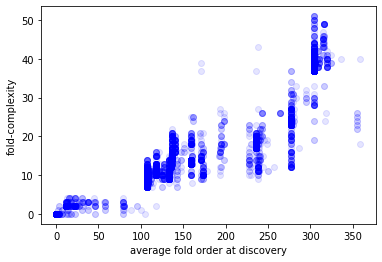

In [258]:
scatter(cpd2coAveMean, cpd2req_foldsNum, 'average fold order at discovery', 'fold-complexity')

In [259]:
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

In [266]:
# bokeh plot: average fold order

output_file("cpd_order_vs_fold_complexity.html")
p = figure(plot_width=800, plot_height=800, title="average fold_order at cpd discovery vs. fold-complexity")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
keys, data1, data2 = todata(cpd2coAveMean, cpd2req_foldsNum)

bools = [key in post_O2_cpds for key in keys]
keys_true = [key for key, flag in zip(keys, bools) if flag]
keys_false = [key for key, flag in zip(keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [cpd2name.get(key, 'no name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [cpd2name.get(key, 'no name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'average fold_order at cpd discovery'
p.yaxis.axis_label = 'fold-complexity'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

### use propero 64

In [267]:
cpd2coAve_64 = csv2dict('../data/assets/cpd2co_ave64.csv')

In [268]:
cpd2coAveMean64 = {key:values[0] for key, values in cpd2coAve_64.items()}

In [270]:
cpd2coAveMean64['C00007']

283.90625

In [269]:
# bokeh plot: average fold order

output_file("cpd_order_vs_fold_complexity.html")
p = figure(plot_width=800, plot_height=800, title="average fold_order at cpd discovery vs. fold-complexity")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
keys, data1, data2 = todata(cpd2coAveMean64, cpd2req_foldsNum)

bools = [key in post_O2_cpds for key in keys]
keys_true = [key for key, flag in zip(keys, bools) if flag]
keys_false = [key for key, flag in zip(keys, bools) if not flag]
data1_true = [value for value, flag in zip(data1, bools) if flag]
data2_true = [value for value, flag in zip(data2, bools) if flag]
data1_false = [value for value, flag in zip(data1, bools) if not flag]
data2_false = [value for value, flag in zip(data2, bools) if not flag]

source = {'x': data1_false, 'y': data2_false, 'label': [cpd2name.get(key, 'no name') for key in keys_false]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
source = {'x': data1_true, 'y': data2_true, 'label': [cpd2name.get(key, 'no name') for key in keys_true]}
p.scatter('x', 'y', source=source, size=10, color='red', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'average fold_order at cpd discovery'
p.yaxis.axis_label = 'fold-complexity'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [272]:
print(group1)

['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']


In [273]:
print(first10)

['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']
